In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
def step(x):
    return 1 if x >= 0 else 0

In [6]:
def plot_boundary(X, y, w, b, title, ax):

    for i in range(len(X)):
        if y[i]==1:
            ax.scatter(X[i][0],X[i][1],color="blue",s=100)
        else:
            ax.scatter(X[i][0],X[i][1],color="red",s=100)

    x_vals=np.linspace(-0.5,1.5,100)


    if abs(w[1]) > 1e-6:
        y_vals = -(w[0]*x_vals + b) / w[1]
        ax.plot(x_vals, y_vals, 'k')
    elif abs(w[0]) > 1e-6:
        x_intercept = -b / w[0]
        ax.axvline(x_intercept, color='k')

    ax.set_xlim(-0.5,1.5)
    ax.set_ylim(-0.5,1.5)
    ax.grid(True)
    ax.set_title(title)

In [4]:
def perceptron(X,y,epochs=10,lr=1):

    w=np.zeros(2)
    b=0

    plot_data_history = []
    print("Initial Weights:",w)
    print("Initial Bias:",b)

    for epoch in range(epochs):

        print("\nEpoch",epoch+1)

        for i in range(len(X)):

            net=np.dot(X[i],w)+b

            pred=step(net)

            error=y[i]-pred

            if error!=0:

                w=w+lr*error*X[i]
                b=b+lr*error

                print("----------------------")
                print("Update",len(plot_data_history)+1)
                print("Input :",X[i])
                print("Target:",y[i])
                print("Prediction:",pred)
                print("Weights:",w)
                print("Bias:",b)


                plot_data_history.append({
                    'w': w.copy(),
                    'b': b,
                    'title': f"Update {len(plot_data_history)+1}"
                })

    print("\nFinal Weights:",w)
    print("Final Bias:",b)
    return plot_data_history

Initial Weights: [0. 0.]
Initial Bias: 0

Epoch 1
----------------------
Update 1
Input : [0 0]
Target: 0
Prediction: 1
Weights: [0. 0.]
Bias: -1
----------------------
Update 2
Input : [0 1]
Target: 1
Prediction: 0
Weights: [0. 1.]
Bias: 0
----------------------
Update 3
Input : [1 1]
Target: 0
Prediction: 1
Weights: [-1.  0.]
Bias: -1

Epoch 2
----------------------
Update 4
Input : [0 1]
Target: 1
Prediction: 0
Weights: [-1.  1.]
Bias: 0
----------------------
Update 5
Input : [1 0]
Target: 1
Prediction: 0
Weights: [0. 1.]
Bias: 1
----------------------
Update 6
Input : [1 1]
Target: 0
Prediction: 1
Weights: [-1.  0.]
Bias: 0

Epoch 3
----------------------
Update 7
Input : [0 0]
Target: 0
Prediction: 1
Weights: [-1.  0.]
Bias: -1
----------------------
Update 8
Input : [0 1]
Target: 1
Prediction: 0
Weights: [-1.  1.]
Bias: 0
----------------------
Update 9
Input : [1 0]
Target: 1
Prediction: 0
Weights: [0. 1.]
Bias: 1
----------------------
Update 10
Input : [1 1]
Target: 0
Predict

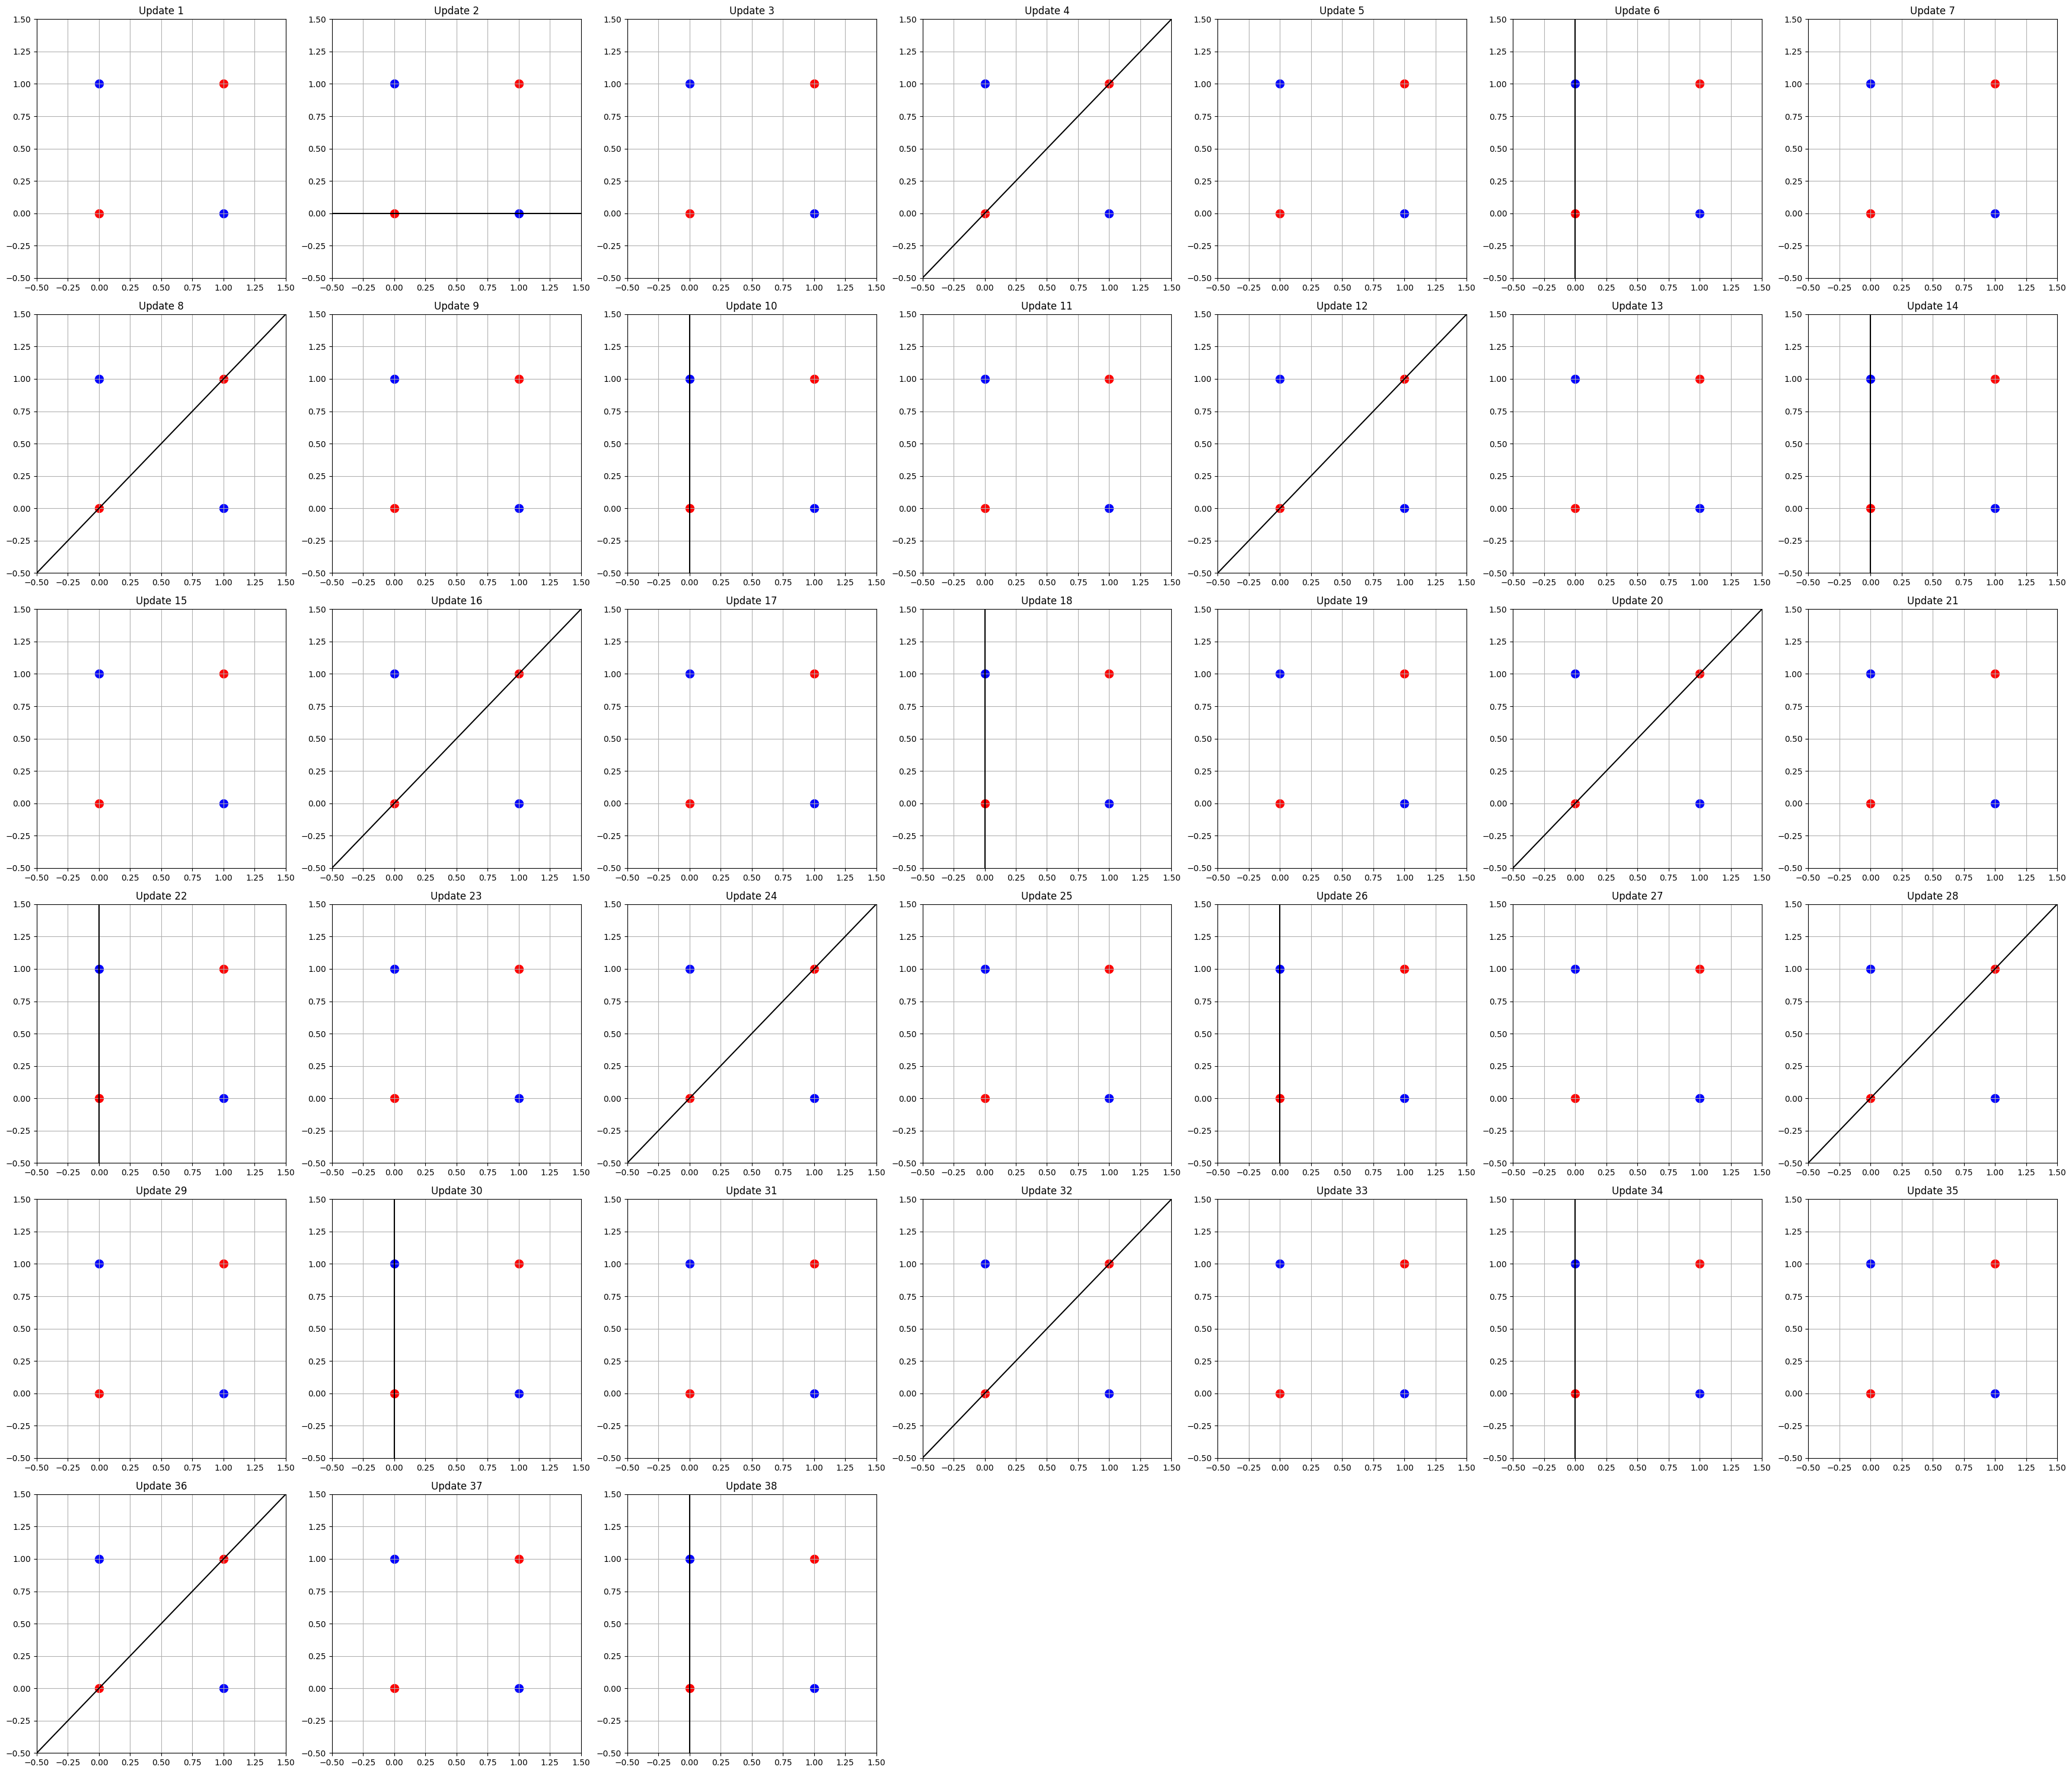

In [7]:
X=np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y=np.array([
    0,
    1,
    1,
    0
])


plot_data_list = perceptron(X,y,epochs=10)


num_plots = len(plot_data_list)

cols = int(np.ceil(np.sqrt(num_plots)))
rows = int(np.ceil(num_plots / cols))


fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5))


if num_plots == 1:
    axes = [axes]
else:
    axes = axes.flatten()


for i, data in enumerate(plot_data_list):
    if i < len(axes):
        plot_boundary(X, y, data['w'], data['b'], data['title'], axes[i])


for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('perceptron_updates.pdf', dpi=600)
plt.show()

## Multi-Layer Perceptron for XOR

The single-layer perceptron you just implemented is limited to solving linearly separable problems. The XOR (exclusive OR) function is not linearly separable, meaning a single straight line (or hyperplane in higher dimensions) cannot perfectly separate the `0` outputs from the `1` outputs. This is why the perceptron continued to update its weights but couldn't converge to a solution for XOR.

A Multi-Layer Perceptron (MLP), also known as a feedforward neural network, overcomes this limitation by introducing one or more 'hidden layers' of neurons. These hidden layers allow the network to learn non-linear relationships and effectively solve problems like XOR.

In [8]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

In [9]:
class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):

        self.W1 = np.random.uniform(size=(input_size, hidden_size))
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.uniform(size=(hidden_size, output_size))
        self.b2 = np.zeros((1, output_size))
        self.learning_rate = learning_rate

    def forward(self, X):

        self.hidden_input = np.dot(X, self.W1) + self.b1
        self.hidden_output = sigmoid(self.hidden_input)


        self.output_input = np.dot(self.hidden_output, self.W2) + self.b2
        self.output = sigmoid(self.output_input)
        return self.output

    def backward(self, X, y, output):

        output_error = y - output
        output_delta = output_error * sigmoid_derivative(output)


        hidden_error = output_delta.dot(self.W2.T)
        hidden_delta = hidden_error * sigmoid_derivative(self.hidden_output)


        self.W2 += self.hidden_output.T.dot(output_delta) * self.learning_rate
        self.b2 += np.sum(output_delta, axis=0, keepdims=True) * self.learning_rate
        self.W1 += X.T.dot(hidden_delta) * self.learning_rate
        self.b1 += np.sum(hidden_delta, axis=0, keepdims=True) * self.learning_rate

    def train(self, X, y, epochs):
        for epoch in range(epochs):
            output = self.forward(X)
            self.backward(X, y, output)
            if (epoch + 1) % 1000 == 0:
                loss = np.mean(np.square(y - output))
                print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

In [10]:
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y_xor = np.array([
    [0],
    [1],
    [1],
    [0]
])


mlp = MLP(input_size=2, hidden_size=4, output_size=1, learning_rate=0.1)

print("Training MLP for XOR:")
mlp.train(X_xor, y_xor, epochs=10000)

print("\nMLP Predictions for XOR:")
predictions = mlp.forward(X_xor)
binary_predictions = (predictions >= 0.5).astype(int)

results_df = pd.DataFrame({
    'Input X1': X_xor[:, 0],
    'Input X2': X_xor[:, 1],
    'Expected Output': y_xor.flatten(),
    'Predicted Output (raw)': predictions.flatten(),
    'Predicted Output (binary)': binary_predictions.flatten()
})
display(results_df)

if np.array_equal(y_xor.flatten(), binary_predictions.flatten()):
    print("\nMLP successfully solved the XOR problem!")
else:
    print("\nMLP did not perfectly solve the XOR problem. Try adjusting epochs or learning rate.")

Training MLP for XOR:
Epoch 1000, Loss: 0.2389
Epoch 2000, Loss: 0.1855
Epoch 3000, Loss: 0.0945
Epoch 4000, Loss: 0.0263
Epoch 5000, Loss: 0.0116
Epoch 6000, Loss: 0.0069
Epoch 7000, Loss: 0.0047
Epoch 8000, Loss: 0.0036
Epoch 9000, Loss: 0.0028
Epoch 10000, Loss: 0.0023

MLP Predictions for XOR:


,Input X1,Input X2,Expected Output,Predicted Output (raw),Predicted Output (binary)
0,0,0,0,0.052399,0
1,0,1,1,0.953600,1
2,1,0,1,0.953742,1
3,1,1,0,0.047577,0



MLP successfully solved the XOR problem!


### Visualizing the MLP's Decision Boundary for XOR

To understand how the MLP successfully learned the XOR function, let's visualize its decision boundary. Unlike the single perceptron, the MLP creates a non-linear boundary to separate the classes.

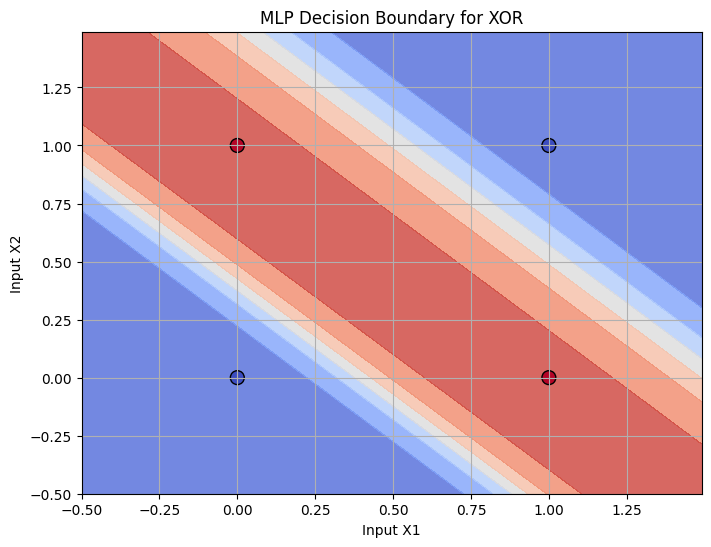

In [11]:
x_min, x_max = X_xor[:, 0].min() - 0.5, X_xor[:, 0].max() + 0.5
y_min, y_max = X_xor[:, 1].min() - 0.5, X_xor[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                     np.arange(y_min, y_max, 0.01))


Z = mlp.forward(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.flatten(), cmap=plt.cm.coolwarm, edgecolors='k', s=100)
plt.xlabel('Input X1')
plt.ylabel('Input X2')
plt.title('MLP Decision Boundary for XOR')
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.grid(True)


plt.savefig('mlp_xor_decision_boundary.pdf', dpi=600)
plt.show()